In [429]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns

In [430]:
df=pd.read_csv('manufacturing.csv')

In [431]:
df.duplicated().any()

np.False_

In [432]:
df.isnull().any()

Temperature (°C)                  False
Pressure (kPa)                    False
Temperature x Pressure            False
Material Fusion Metric            False
Material Transformation Metric    False
Quality Rating                    False
dtype: bool

In [433]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (°C)                3957 non-null   float64
 1   Pressure (kPa)                  3957 non-null   float64
 2   Temperature x Pressure          3957 non-null   float64
 3   Material Fusion Metric          3957 non-null   float64
 4   Material Transformation Metric  3957 non-null   float64
 5   Quality Rating                  3957 non-null   float64
dtypes: float64(6)
memory usage: 185.6 KB


In [434]:
df.corr()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
Temperature (°C),1.000000,-0.024754,0.571743,0.974901,0.971210,-0.461279
Pressure (kPa),-0.024754,1.000000,0.773572,0.151095,-0.022862,0.013129
Temperature x Pressure,0.571743,0.773572,1.000000,0.694733,0.555579,-0.258474
Material Fusion Metric,0.974901,0.151095,0.694733,1.000000,0.976708,-0.511972
Material Transformation Metric,0.971210,-0.022862,0.555579,0.976708,1.000000,-0.575756
Quality Rating,-0.461279,0.013129,-0.258474,-0.511972,-0.575756,1.000000


it is a non linear data 

<Axes: xlabel='Temperature (°C)', ylabel='Quality Rating'>

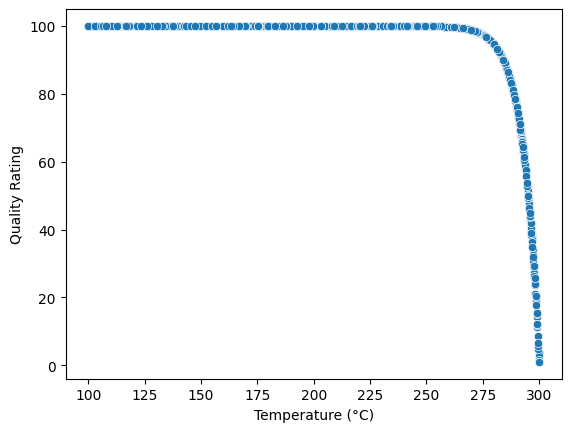

In [435]:
sns.scatterplot(df,x='Temperature (°C)',y='Quality Rating')

In [436]:
x=df.drop(columns='Quality Rating')
y=df['Quality Rating']

In [437]:
#plt.scatter(x,y)
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [438]:
model=LinearRegression()
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.32,-0.05,-0. , 0. ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Temperature (°C)','Pressure (kPa)','Temperature x Pressure', 'Material Fusion Metric','Material Transformation Metric']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,61.92
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [439]:
#model Evaluvation
ytrain_predicted=model.predict(xtrain)
train_score=r2_score(ytrain,ytrain_predicted)
print(train_score)

ytest_predicted=model.predict(xtest)
test_score=r2_score(ytest,ytest_predicted)
print(test_score)

0.4990832111258189
0.5138958719206155


In [440]:
xtrain

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric
2533,216.199164,9.621265,2080.109475,47632.706816,1.010551e+07
1613,178.624483,12.048327,2152.126171,33655.667371,5.699174e+06
3347,159.225345,16.660873,2652.833232,29977.513751,4.036517e+06
1117,107.032012,22.092997,2364.657879,22239.454281,1.225655e+06
3591,125.084376,13.242953,1656.486513,17968.594689,1.956907e+06
...,...,...,...,...,...
1130,100.412927,20.827861,2091.386466,19117.877447,1.012005e+06
1294,104.953812,14.896303,1563.423745,14320.789657,1.155876e+06
860,287.423408,10.143206,2915.394894,83655.795723,2.374458e+07
3507,142.741438,20.320083,2900.517791,28765.396998,2.907961e+06


In [441]:
poly=PolynomialFeatures(degree=9)
updated_xtrain=poly.fit_transform(xtrain)
updated_xtest=poly.transform(xtest)

In [442]:
model_poly=LinearRegression()
model_poly.fit(updated_xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2002,)","[-0.,-0., 0.,..., 0., 0.,-0.]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,100.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2002
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2002,)","[6.81e+67,1.37e+64,1.85e+63,...,4.92e+51,4.59e+51,1.49e+51]"


In [443]:
ytrain_predicted=model_poly.predict(updated_xtrain)
train_score=r2_score(ytrain,ytrain_predicted)
print(train_score)

ytest_predicted=model_poly.predict(updated_xtest)
test_score=r2_score(ytest,ytest_predicted)
print(test_score)

0.9766873472208099
0.976106765677322
